In [11]:
# %pip install xgboost

import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from scipy.stats import randint, uniform
import joblib

### Data Preprocessing

In [12]:
df = pd.read_csv("./datasets/final.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15689,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
1,15690,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,77.126264
2,15691,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt

### Identity the features and targets for this model

In [13]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "mem",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["problem", "name", "nvar"]                                                                                                                   # [...]   
first = list(set(group_key + feature_cols_reg + target_cols_reg  + target_col_model))
df = df[first + [c for c in df.columns if c not in first]]    
df                                                                                       # [1, x41 x42 ... x44]

,tree_length,mem,tree_depth,count_exponential_function,name,stats_elapsed_time,alloc_grad,time_obj,extract_duration_problem,total_alloc,count_plus_minus,timed_bytes,alloc_obj,count_trigonometric_function,nvar,problem,neval_obj,neval_grad,eval_duration_problem,time_grad,count_op_function,highest_degree (ExprTree),index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type
0,10404.0,1,9.0,0.0,arglina,0.000135,4.261110e+07,0.376715,4.309682,77.126264,305.0,18576.0,34515160.0,0.0,100,OptimizationProb...,4.0,4.0,1.980544,0.464686,509.0,2.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
1,10404.0,2,9.0,0.0,arglina,0.000151,4.261110e+07,0.376715,4.309682,77.126264,305.0,22120.0,34515160.0,0.0,100,OptimizationProb...,2.0,2.0,1.980544,0.464686,509.0,2.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
2,10404.0,3,9.0,0.0,arglina,0.000140,4.261110e+07,0.376715,4.309682,77.126264,305.0,25592.0,34515160.0,0.0,100,OptimizationProb...,2.0,2.0,1.980544,0.464686,509.0,2.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [14]:
df = df.copy()
df["mem_count"] = df.groupby(["problem", "name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df.to_csv("./datasets/final_cleaned.csv", index=False)

In [15]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df

,tree_length,mem,tree_depth,count_exponential_function,name,stats_elapsed_time,alloc_grad,time_obj,extract_duration_problem,total_alloc,count_plus_minus,timed_bytes,alloc_obj,count_trigonometric_function,nvar,problem,neval_obj,neval_grad,eval_duration_problem,time_grad,count_op_function,highest_degree (ExprTree),index,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,10404.0,1,9.0,0.0,arglina,0.000135,42611104.0,0.376715,4.309682,77.126264,305.0,18576.0,34515160.0,0.0,100,OptimizationProb...,4.0,4.0,1.980544,0.464686,509.0,2.0,15689,1.0,5.000000e+01,0.319062,0.011306,7.841650e-15,first_order,0.000164,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,10404.0,2,9.0,0.0,arglina,0.000151,42611104.0,0.376715,4.309682,77.126264,305.0,22120.0,34515160.0,0.0,100,OptimizationProb...,2.0,2.0,1.980544,0.464686,509.0,2.0,15690,1.0,5.000000e+01,0.319062,0.011309,7.841650e-15,first_order,0.000199,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,0.0,NaN,0.0,5050.0,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,10404.0,3,9.0,0.0,arglina,0.000140,42611104.0,0.376715,4.309682,77.126264,305.0,25592.0,34515160.0,0.0,100,OptimizationProb...,2.0,2.0,1.980544,0.464686,509.0,2.0,15691,1.0,5.000000e+01,0.319062,0.011275,7.841650e-15,first_order,0.000182,0.000000,0.377710,1.0,OptimizationProb...,2026-02-28 18:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,1.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,1.0,0.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,NaN,ADNLPModels.Empt...,0.0,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,Fal

In [16]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].dropna(axis=1).to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].dropna(axis=1).to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)
X_train.shape

(16000, 16)

### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [17]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Gradient Boosting

In [18]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': randint(3, 15),  # XGBoost typically uses shallower trees
#     'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.3
#     'subsample': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bytree': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bylevel': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bynode': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'min_child_weight': randint(1, 20),
#     'gamma': uniform(0, 0.5),  # min loss reduction
#     'reg_alpha': uniform(0, 10),  # L1 regularization
#     'reg_lambda': uniform(0, 10),  # L2 regularization
# }

# xgb_model = xgb.XGBRegressor(
#     objective='reg:squarederror', 
#     random_state=42, 
#     n_jobs=1,
#     tree_method='hist',  # faster training
# )

# random_search = RandomizedSearchCV(
#     xgb_model,
#     param_distributions=param_distributions,
#     n_iter=20, 
#     cv=3,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
# )

# random_search.fit(X_train, y_train)

# # Results
# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# # Save detailed results
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# # Top 20 configurations
# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_learning_rate',
#             'param_subsample', 'param_colsample_bytree', 'param_min_child_weight']
# print(results_df[top_cols].head(20).to_string())

# # Save to CSV
# results_df.to_csv('xgb_randomsearch_comprehensive_results.csv', index=False)
# print(f"\nFull results saved to xgb_randomsearch_comprehensive_results.csv")

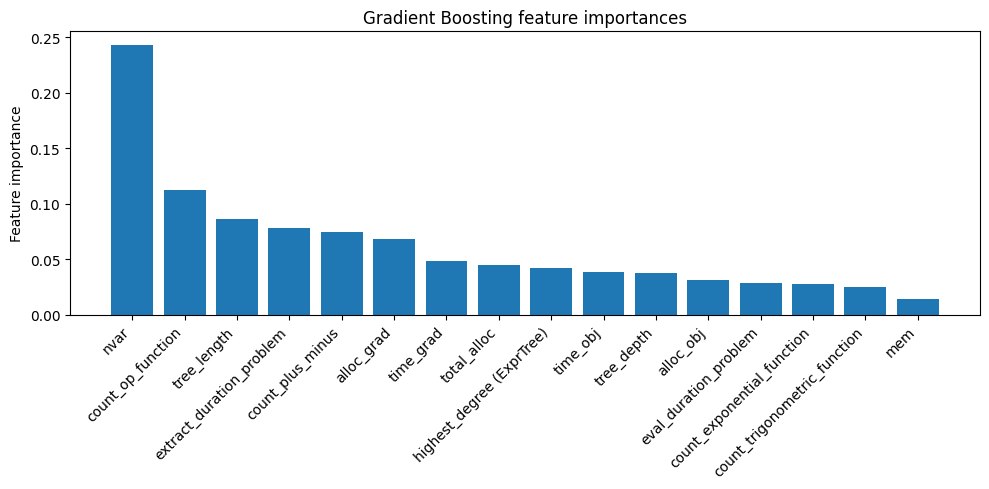

['./model_weights/best_gb_model_reg.pkl']

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os 

path = './model_weights/best_gb_model_reg.pkl'

best_model = joblib.load('./model_weights/best_gb_model_reg.pkl')
gb_importances = best_model.feature_importances_
indices_rf = np.argsort(gb_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), gb_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Gradient Boosting feature importances")
plt.tight_layout()
plt.show()

joblib.dump(best_model, './model_weights/best_gb_model_reg.pkl')

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=0.6660  R²=0.8306

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  63.27%
  <  10%:  67.49%
  <  15%:  70.54%
  <  20%:  75.32%
  <  30%:  83.46%
  <  50%:  96.59%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  66.00%
  <  10%:  68.34%
  <  15%:  70.83%
  <  20%:  75.20%
  <  30%:  82.29%
  <  50%:  94.39%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  91.07%
  <  10%:  95.73%
  <  15%:  98.22%
  <  20%:  99.46%
  <  30%:  99.98%
  <  50%:  100.00%


[]

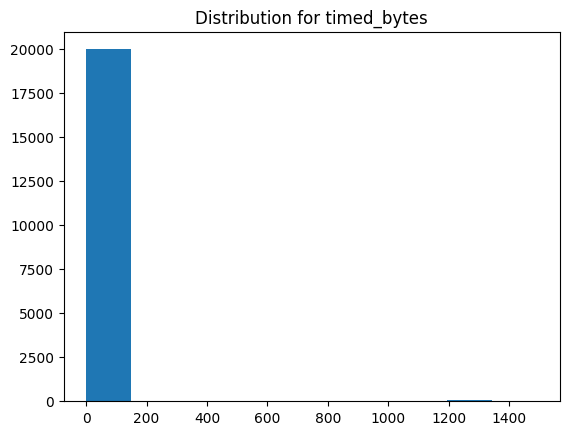

In [21]:
x = df["timed_bytes"] / 10**8
x = x[x < 2000]
plt.hist(x=x)
plt.title("Distribution for timed_bytes")
plt.plot()

### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [22]:
X_train_time = pd.concat([
    train_df[target_cols_reg],
    train_df[['mem']]
], axis=1)
X_test_time = pd.concat([
    test_df[target_cols_reg],
    test_df[['mem']]
], axis=1)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [23]:
time_predictor = xgb.XGBRegressor(objective='reg:squarederror')
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.6123289445582611

In [24]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': randint(3, 15),  # XGBoost typically uses shallower trees
#     'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.3
#     'subsample': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bytree': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bylevel': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'colsample_bynode': uniform(0.5, 0.5),  # 0.5 to 1.0
#     'min_child_weight': randint(1, 20),
#     'gamma': uniform(0, 0.5),  # min loss reduction
#     'reg_alpha': uniform(0, 10),  # L1 regularization
#     'reg_lambda': uniform(0, 10),  # L2 regularization
# }

# rf = xgb.XGBRegressor(
#     random_state=42, 
#     n_jobs=-1,
#     tree_method='hist'  # faster training
# )

# time_random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50,
#     cv=5,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
#     error_score='raise'
# )

# time_random_search.fit(X_train_time, y_train_time)


In [25]:
time_best_model = joblib.load('./model_weights/best_gb_model_time.pkl')
# time_best_model = time_random_search.best_estimator_
# time_best_model = time_random_search.best_estimator_
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_gb_model_time.pkl')

Time prediction accuracy based on predicted values=0.8244277455076676


['./model_weights/best_gb_model_time.pkl']

In [26]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=0.6960  R²=0.8244

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  17.34%
  <  10%:  25.41%
  <  15%:  30.22%
  <  20%:  34.71%
  <  30%:  40.05%
  <  50%:  48.49%


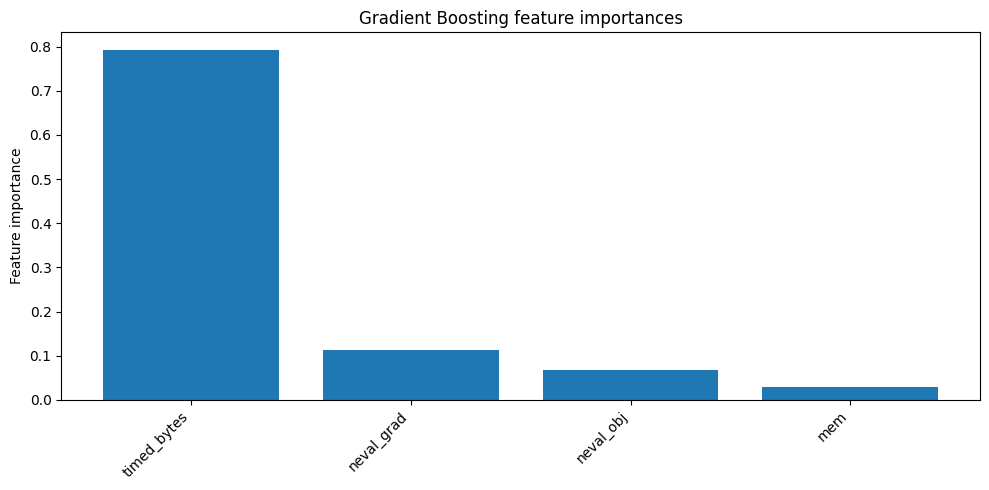

In [27]:
best_model_time_raw = time_best_model
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

feature_names_stage2 = target_cols_reg + ['mem']

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names_stage2)), rf_importances[indices_rf])
plt.xticks(range(len(feature_names_stage2)), [feature_names_stage2[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Gradient Boosting feature importances")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [28]:
time_predictor =  xgb.XGBRegressor(objective='reg:squarederror')
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.6123289445582611

In [29]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': randint(3, 15),
#     'learning_rate': uniform(0.01, 0.29),
#     'subsample': uniform(0.5, 0.5),
#     'colsample_bytree': uniform(0.5, 0.5),
#     'colsample_bylevel': uniform(0.5, 0.5),
#     'colsample_bynode': uniform(0.5, 0.5),
#     'min_child_weight': randint(1, 20),
#     'gamma': uniform(0, 0.5),
#     'reg_alpha': uniform(0, 10),
#     'reg_lambda': uniform(0, 10),
# }

# rf = xgb.XGBRegressor(
#     random_state=42, 
#     n_jobs=-1,
#     tree_method='hist'
# )

# time_random_search_raw = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=500,
#     cv=10,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=3,
#     return_train_score=True
# )

# time_random_search_raw.fit(X_train_time, y_train_time)

In [30]:
# time_best_model_raw = time_random_search_raw.best_estimator_
time_best_model_raw = joblib.load('./model_weights/best_gb_model_time_raw.pkl')
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_gb_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.8449463458554787


['./model_weights/best_gb_model_time_raw.pkl']

In [31]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=0.6147  R²=0.8449

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  19.32%
  <  10%:  27.15%
  <  15%:  31.20%
  <  20%:  34.66%
  <  30%:  40.02%
  <  50%:  49.22%


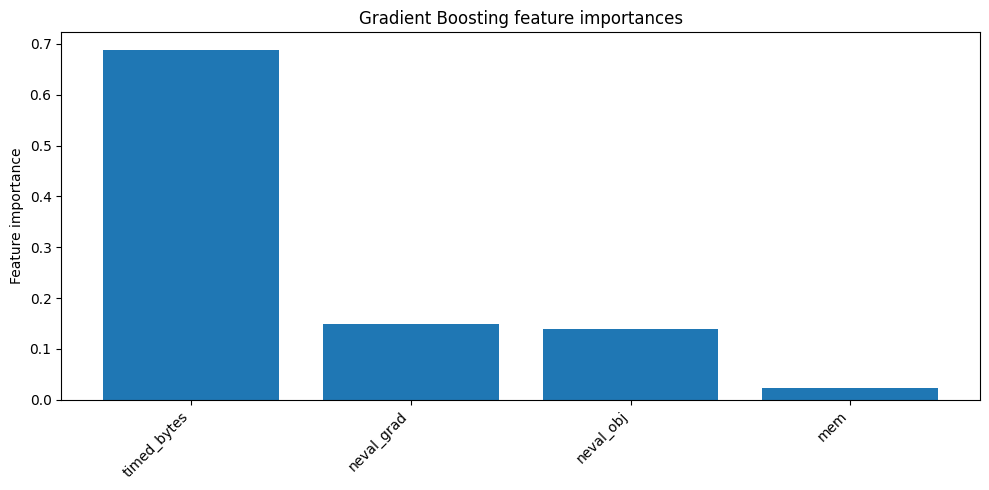

In [32]:
best_model_time_raw = time_best_model_raw
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

feature_names_stage2 = target_cols_reg + ['mem']

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names_stage2)), rf_importances[indices_rf])
plt.xticks(range(len(feature_names_stage2)), [feature_names_stage2[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Gradient Boosting feature importances")
plt.tight_layout()
plt.show()

### Now let's use stats_ellapsed_time to predict the corresponding best mem value

In [33]:
test_df["predicted_time"] = time_best_model_raw.predict(X_test_time)
test_df["predicted_time"]

0      -0.037518
1      -0.158737
2      -0.120724
3      -0.079717
4      -0.046597
          ...   
4095    0.133339
4096    0.106772
4097    0.136345
4098   -0.126427
4099    0.324858
Name: predicted_time, Length: 4100, dtype: float32

In [34]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [35]:
group_cols = ["problem", "name", "nvar"]
best_idx = test_df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_observed_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)


In [36]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [37]:
group_cols = ["problem", "name", "nvar"]
best_idx = test_df.groupby(group_cols)["predicted_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_predicted_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)
test_df["best_predicted_mem"].describe()

count    4100.000000
mean       22.024390
std        30.247001
min         1.000000
25%         3.000000
50%         7.000000
75%        30.000000
max       100.000000
Name: best_predicted_mem, dtype: float64

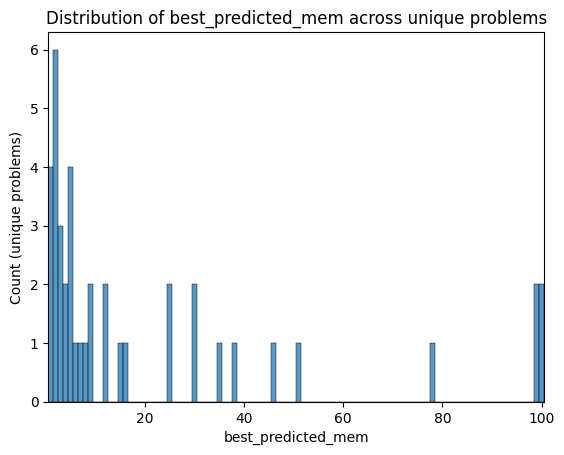

In [38]:
# %pip install seaborn
import seaborn as sns
x = test_df.groupby(['problem', 'name', 'nvar'])['best_predicted_mem'].first()
sns.histplot(x=x, discrete=True)
plt.xlim(0.5, x.max() + 0.5)
plt.xlabel("best_predicted_mem")
plt.ylabel("Count (unique problems)")
plt.title("Distribution of best_predicted_mem across unique problems")
plt.show()

Proportions of best_predicted_mem:
best_predicted_mem
1      0.097561
2      0.146341
3      0.073171
4      0.048780
5      0.097561
6      0.024390
7      0.024390
8      0.024390
9      0.048780
12     0.048780
15     0.024390
16     0.024390
25     0.048780
30     0.048780
35     0.024390
38     0.024390
46     0.024390
51     0.024390
78     0.024390
99     0.048780
100    0.048780
Name: proportion, dtype: float64


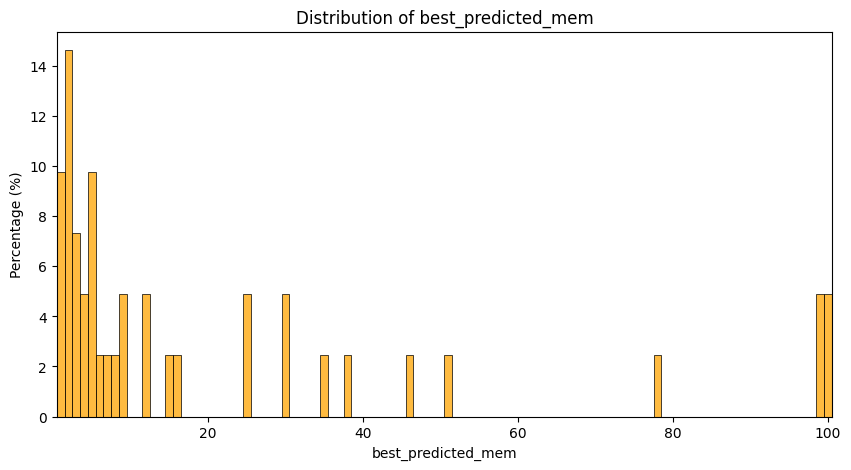

In [39]:
x = test_df["best_predicted_mem"]
proportions = x.value_counts(normalize=True).sort_index()

print("Proportions of best_predicted_mem:")
print(proportions)

plt.figure(figsize=(10, 5))
sns.histplot(x=x, stat='percent', discrete=True, color='orange')
plt.xlabel("best_predicted_mem")
plt.ylabel("Percentage (%)")
plt.title("Distribution of best_predicted_mem")
plt.xlim(0.5, x.max() + 0.5)
plt.show()

### Mem evaluation metrics

In [40]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(test_df['best_predicted_mem'] - test_df['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 16.34
Median Absolute Mem Error: 6.00


In [41]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem']) / \
                  np.maximum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.511


In [42]:
group_cols = ['problem', 'name', 'nvar']
unique_problems = test_df.groupby(group_cols).first().reset_index()

print(f"Total unique test problems: {len(unique_problems)}\n")

Total unique test problems: 41



In [43]:
print("="*60)
print("MEM PREDICTION ACCURACY")
print("="*60)

exact_match = (unique_problems['best_predicted_mem'] == unique_problems['best_observed_mem']).mean()
print(f"Exact match rate: {exact_match:.1%}")

within_5 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 5).mean()
within_10 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 10).mean()
within_20 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 20).mean()

print(f"\nWithin tolerance:")
print(f"  ± 5 mem units:  {within_5:.1%}")
print(f"  ± 10 mem units: {within_10:.1%}")
print(f"  ± 20 mem units: {within_20:.1%}")

MEM PREDICTION ACCURACY
Exact match rate: 9.8%

Within tolerance:
  ± 5 mem units:  48.8%
  ± 10 mem units: 63.4%
  ± 20 mem units: 78.0%


In [44]:
print("="*60)
print("RUNTIME REGRET")
print("="*60)

optimal_times = test_df.groupby(group_cols)['stats_elapsed_time'].min()
predicted_mem_times = test_df.set_index(group_cols + ['mem']).loc[
    [(g[0], g[1], g[2], g[3]) for g in unique_problems[group_cols + ['best_predicted_mem']].itertuples(index=False)]
]['stats_elapsed_time'].values

absolute_regret = predicted_mem_times - optimal_times.values
relative_regret = (absolute_regret / optimal_times.values) * 100

print(f"Mean relative regret: {relative_regret.mean():.2f}%")
print(f"Median relative regret: {np.median(relative_regret):.2f}%")

print(f"\nRegret distribution:")
print(f"  < 5% regret:  {(relative_regret < 5).mean():.1%}")
print(f"  < 10% regret: {(relative_regret < 10).mean():.1%}")
print(f"  < 20% regret: {(relative_regret < 20).mean():.1%}")
print(f"  < 50% regret: {(relative_regret < 50).mean():.1%}")

RUNTIME REGRET
Mean relative regret: 26.31%
Median relative regret: 8.16%

Regret distribution:
  < 5% regret:  29.3%
  < 10% regret: 53.7%
  < 20% regret: 70.7%
  < 50% regret: 87.8%


In [45]:
print("="*60)
print("RANKING QUALITY")
print("="*60)

from scipy.stats import spearmanr

rank_corrs = []
for _, group_data in test_df.groupby(group_cols):
    true_order = group_data.sort_values('mem')['stats_elapsed_time'].values
    pred_order = group_data.sort_values('mem')['predicted_time'].values
    corr, _ = spearmanr(true_order, pred_order)
    rank_corrs.append(corr)

print(f"Mean Spearman correlation: {np.mean(rank_corrs):.3f}")
print(f"Median Spearman correlation: {np.median(rank_corrs):.3f}")

RANKING QUALITY
Mean Spearman correlation: 0.232
Median Spearman correlation: 0.233
